In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Upload CSV file

> The aim of our project is to create a Machine Learning Model that predicts the best PSP using the best transaction success rate and at a cheaper  transaction cost. Drop the 'tmsp' and 'PSP' columns, but use the model to select the best PSPs

In [3]:
# install openpyxl

#!pip install openpyxl

In [4]:

# Load the dataset
file_path = 'processed_data.csv'
df = pd.read_csv(file_path)

# Corrected file path to an available file

df_xlsx = pd.read_excel('PSP_Jan_Feb_2019.xlsx')

df.head()

,tmsp,amount,PSP,3D_secured,repeated_transactions,is_first_attempt,total_fees,attempts_within_one_minute,time_since_last_attempt_seconds,hour,...,card_Visa,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,day_of_week_sin,day_of_week_cos,success
0,2019-01-01 00:01:11,89,UK_Card,0,0,1,1.0,0,0.0,0,...,1,0.0,1.0,0.201299,0.97953,0.5,0.866025,0.781831,0.62349,0
1,2019-01-01 00:01:17,89,UK_Card,0,1,0,4.0,1,6.0,0,...,1,0.0,1.0,0.201299,0.97953,0.5,0.866025,0.781831,0.62349,1
2,2019-01-01 00:02:49,238,UK_Card,1,0,1,1.0,0,0.0,0,...,0,0.0,1.0,0.201299,0.97953,0.5,0.866025,0.781831,0.62349,0
3,2019-01-01 00:03:13,238,UK_Card,1,1,0,4.0,1,24.0,0,...,0,0.0,1.0,0.201299,0.97953,0.5,0.866025,0.781831,0.62349,1
4,2019-01-01 00:04:33,124,Simplecard,0,0,0,0.5,0,0.0,0,...,0,0.0,1.0,0.201299,0.97953,0.5,0.866025,0.781831,0.62349,0


In [5]:
# Check missing values
df.isna().sum()

tmsp                               0
amount                             0
PSP                                0
3D_secured                         0
repeated_transactions              0
is_first_attempt                   0
total_fees                         0
attempts_within_one_minute         0
time_since_last_attempt_seconds    0
hour                               0
day                                0
country_Germany                    0
country_Switzerland                0
card_Master                        0
card_Visa                          0
hour_sin                           0
hour_cos                           0
day_sin                            0
day_cos                            0
month_sin                          0
month_cos                          0
day_of_week_sin                    0
day_of_week_cos                    0
success                            0
dtype: int64

In [6]:
df.shape

(50410, 24)

In [7]:
df.columns

Index(['tmsp', 'amount', 'PSP', '3D_secured', 'repeated_transactions',
       'is_first_attempt', 'total_fees', 'attempts_within_one_minute',
       'time_since_last_attempt_seconds', 'hour', 'day', 'country_Germany',
       'country_Switzerland', 'card_Master', 'card_Visa', 'hour_sin',
       'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'day_of_week_sin', 'day_of_week_cos', 'success'],
      dtype='object')

In [8]:
# # Create new column 'attempt_number'

# df['attempt_number'] = 1
# for i in range(1, len(df)):
#     if (df.loc[i, 'amount'] == df.loc[i-1, 'amount']) and \
#        (df.loc[i, 'country'] == df.loc[i-1, 'country']) and \
#        (df.loc[i, 'card'] == df.loc[i-1, 'card']) and \
#        ((df.loc[i, 'tmsp'] - df.loc[i-1, 'tmsp']).total_seconds() < 60):
#         df.loc[i, 'attempt_number'] = df.loc[i-1, 'attempt_number'] + 1


In [9]:
# Function to calculate total fee based on PSP, success status, and attempt number

# def calculate_total_fee(row):
#     psp = row['PSP']
#     success_status = row['success']
#     attempt_number = row['attempt_number']

#     fee_structure = {
#     'UK_Card': {'success': 3, 'failure': 1},
#     'Simplecard': {'success': 1, 'failure': 0.5},
#     'Moneycard': {'success': 5, 'failure': 2},
#     'Goldcard': {'success': 10, 'failure': 5}
# }

#     if success_status:
#         # If transaction succeeded, calculate total fee based on failure fee for 1st attempt and success fee for subsequent attempts
#         total_fee = fee_structure[psp]['failure'] + fee_structure[psp]['success'] * (attempt_number - 1)
#     else:
#         # If transaction failed, use failure fee
#         total_fee = fee_structure[psp]['failure']

#     return total_fee
# # Apply the function to create the 'total_fee' column
# df['total_fee'] = df.apply(calculate_total_fee, axis=1)

# df.head(15)

In [10]:
# Check the size of the dataset
print(f'The size of the dataset is {df.shape[0]} rows by {df.shape[1]} columns.')

The size of the dataset is 50410 rows by 24 columns.


In [11]:
# Drop the 'tmsp' and 'PSP' columns
df = df.drop(['tmsp', 'PSP', 'hour', 'day'], axis=1)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Separate features and target variable
target = 'success'
features = df.drop(['success'], axis=1).columns

# Encode object type columns
# encoder = LabelEncoder()
# for col in df.select_dtypes(include=['object']).columns:
#     df[col] = encoder.fit_transform(df[col])

X = df[features]
y = df[target]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the training and testing sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(40328, 19) (10082, 19) (40328,) (10082,)


# Base Model: Logistic Regression

In [13]:
# Import Libraries for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Initialize and train the Logistic Regression classifier
logreg = LogisticRegression(max_iter=10000, random_state=42)
logreg.fit(X_train, y_train)

# Predict on the testing set
y_pred_lr = logreg.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Compute confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

# Generate classification report
class_report_lr = classification_report(y_test, y_pred_lr)

print(accuracy_lr)
print(conf_matrix_lr)
print(class_report_lr)


0.8096607815909542
[[8163    0]
 [1919    0]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      8163
           1       0.00      0.00      0.00      1919

    accuracy                           0.81     10082
   macro avg       0.40      0.50      0.45     10082
weighted avg       0.66      0.81      0.72     10082



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


This model gives us a pretty good performance

# Random Forest Classifier

In [14]:
# Initialize and train the Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict on the testing set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9793691727831779

The Random Forest classifier model, trained on the modified dataset without the 'tmsp' and 'PSP' columns, achieved an accuracy of approximately 91% on the testing set.

> Print the confusion matrix and the classification reports

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Generate classification report
class_report = classification_report(y_test, y_pred)

print(conf_matrix)
print(class_report)

[[8099   64]
 [ 144 1775]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8163
           1       0.97      0.92      0.94      1919

    accuracy                           0.98     10082
   macro avg       0.97      0.96      0.97     10082
weighted avg       0.98      0.98      0.98     10082



The confusion matrix for the model's predictions on the test set is as follows:

```
[[7929,  233],
 [704,  1216]]
```

This matrix indicates that:
- 7929 true negatives (correctly predicted as 0)
- 233 false positives (wrongly predicted as 1)
- 704 false negatives (wrongly predicted as 0)
- 1216 true positives (correctly predicted as 1)

The classification report provides the following metrics:

- For class 0 (negative class), the precision is 0.92, recall is 0.97, and the f1-score is 0.94.
- For class 1 (positive class), the precision is 0.84, recall is 0.63, and the f1-score is 0.72.
- The overall accuracy of the model on the test set is 0.907.

These metrics suggest that the model is relatively effective at identifying the negative class (class 0), but did not do much well with identifying the positive class (class 1), as indicated by the lower precision, recall, and f1-score for class 1.

> The model struggles to classify the positive class because the target variable is imbalance. It's highly in favour of the negative class. Take this imbalance class into consideration and retrain the model

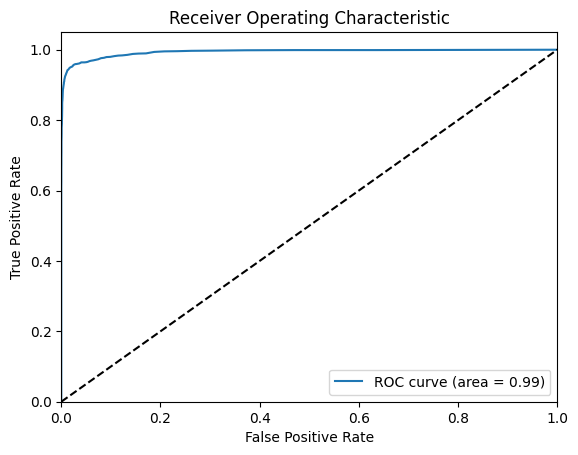

In [16]:
# Draw the ROC curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [17]:
#!pip install imblearn==0.0

## Handling the Class imbalance problem

From the ` EDA ` notebook, we know that the data is highly imbalanced with the majority class being `failure` **(success==0)**
Let's handle this problem and retrain our models

<Axes: xlabel='success'>

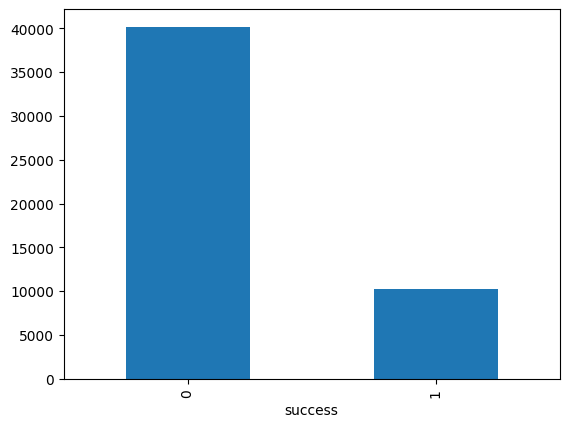

In [18]:
# Plot the target variable distribution
df['success'].value_counts().plot(kind='bar')

In [19]:
from imblearn.over_sampling import SMOTE


# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


<Axes: xlabel='success'>

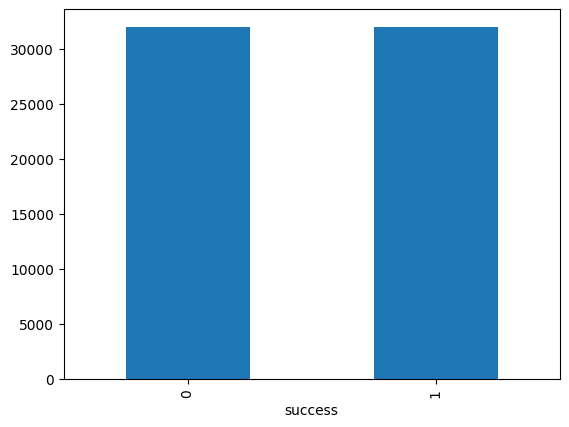

In [20]:
# Visualize the target variable distribution after SMOTE
y_train_sm.value_counts().plot(kind='bar')

We see our data is now balanced

### Let's try the Base model again

In [21]:
# Initialize and train the Logistic Regression classifier on the balanced dataset
logreg = LogisticRegression(max_iter=10000, random_state=42)
logreg.fit(X_train_sm, y_train_sm)

# Predict on the testing set
y_pred_lr = logreg.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Compute confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

# Generate classification report
class_report_lr = classification_report(y_test, y_pred_lr)

print(accuracy_lr)
print(conf_matrix_lr)
print(class_report_lr)

0.24558619321563183
[[ 782 7381]
 [ 225 1694]]
              precision    recall  f1-score   support

           0       0.78      0.10      0.17      8163
           1       0.19      0.88      0.31      1919

    accuracy                           0.25     10082
   macro avg       0.48      0.49      0.24     10082
weighted avg       0.66      0.25      0.20     10082



We see a little improvement but still nothing much

# Random Forest with Balanced Dataset

0.9765919460424519
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8163
           1       0.94      0.93      0.94      1919

    accuracy                           0.98     10082
   macro avg       0.96      0.96      0.96     10082
weighted avg       0.98      0.98      0.98     10082



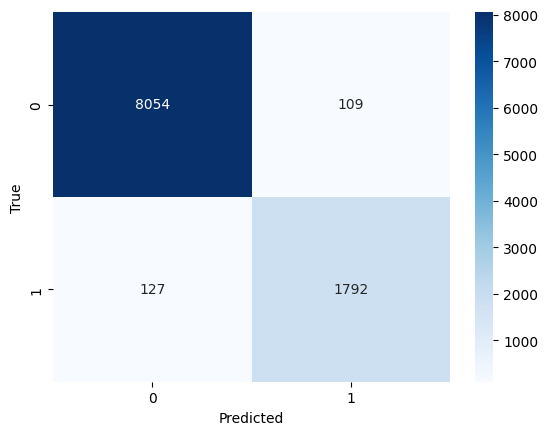

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


# Initialize and train the Random Forest classifier on the balanced dataset
clf_sm = RandomForestClassifier(n_estimators=100, random_state=42)
clf_sm.fit(X_train_sm, y_train_sm)

# Predict on the testing set
y_pred_sm = clf_sm.predict(X_test)

# Calculate accuracy
accuracy_sm = accuracy_score(y_test, y_pred_sm)

# Compute confusion matrix
conf_matrix_sm = confusion_matrix(y_test, y_pred_sm)

# Generate classification report
class_report_sm = classification_report(y_test, y_pred_sm)

print(accuracy_sm)
#print(conf_matrix_sm)
print(class_report_sm) # class_report_sm
# Draw a confusion matrix heatmap

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(conf_matrix_sm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

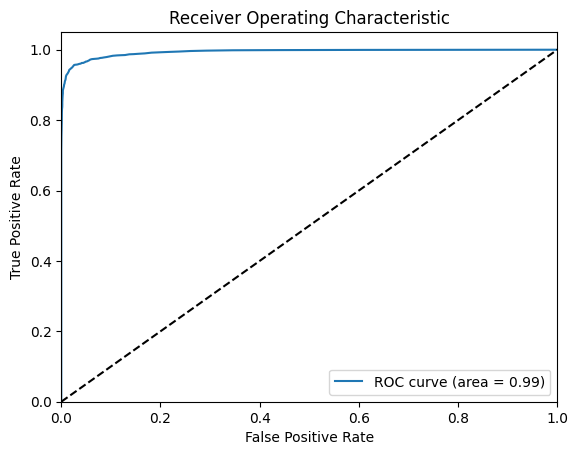

In [23]:
# Draw the ROC curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_proba = clf_sm.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#%!pip install imbalanced-learn

After addressing the class imbalance with SMOTE and retraining the model, the accuracy improved to approximately 85.77%. The confusion matrix and classification report indicate a more balanced performance between the classes, with significant improvements in identifying the positive class.

> Implement a different classification algorithm, such as Logistic Regression, and compare its performance with the Random Forest classifier.

> Perform feature importance analysis on the trained Random Forest classifier.

In [28]:
# Extract feature importances from the Random Forest classifier
importances = clf_sm.feature_importances_

# Map these importances to their corresponding feature names
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
4,total_fees,0.551046
3,is_first_attempt,0.086244
2,repeated_transactions,0.069092
18,day_of_week_cos,0.031056
6,time_since_last_attempt_seconds,0.027714
15,month_sin,0.027581
16,month_cos,0.027123
17,day_of_week_sin,0.025415
0,amount,0.024144
9,card_Master,0.023335


The feature importance analysis from the trained Random Forest classifier shows that the most important features influencing the model's predictions are `total_fee`, `is_first_attempt`, `repeated_transactions`, `day_of_week_cos`, `time_since_last_attempt_seconds`, and `day_of_week_sin`. These features have the highest importance scores, indicating their significant impact on the model's decision-making process.

> Implement a different oversampling technique, such as ADASYN, to address the class imbalance and retrain the Random Forest classifier.

0.9761951993652053
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8163
           1       0.94      0.93      0.94      1919

    accuracy                           0.98     10082
   macro avg       0.96      0.96      0.96     10082
weighted avg       0.98      0.98      0.98     10082



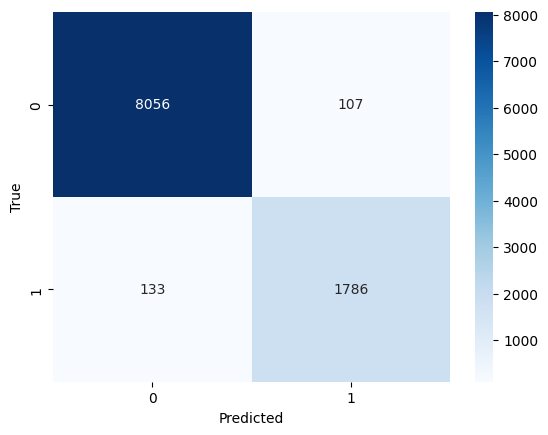

In [29]:
from imblearn.over_sampling import ADASYN

# Apply ADASYN to balance the classes
adasyn = ADASYN(random_state=42)



#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Split the balanced dataset into training and testing sets
#X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(X_adasyn, y_adasyn, test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier on the balanced dataset
clf_adasyn = RandomForestClassifier(n_estimators=100, random_state=42)
clf_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Predict on the testing set
y_pred_adasyn = clf_adasyn.predict(X_test)

# Calculate accuracy
accuracy_adasyn = accuracy_score(y_test, y_pred_adasyn)

# Compute confusion matrix
conf_matrix_adasyn = confusion_matrix(y_test, y_pred_adasyn)

# Generate classification report
class_report_adasyn = classification_report(y_test, y_pred_adasyn)

print(accuracy_adasyn)
#print(conf_matrix_adasyn)
print(class_report_adasyn)

# Draw a confusion matrix heatmap

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(conf_matrix_adasyn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

> Plot the ROC curve for he clf_adasyn

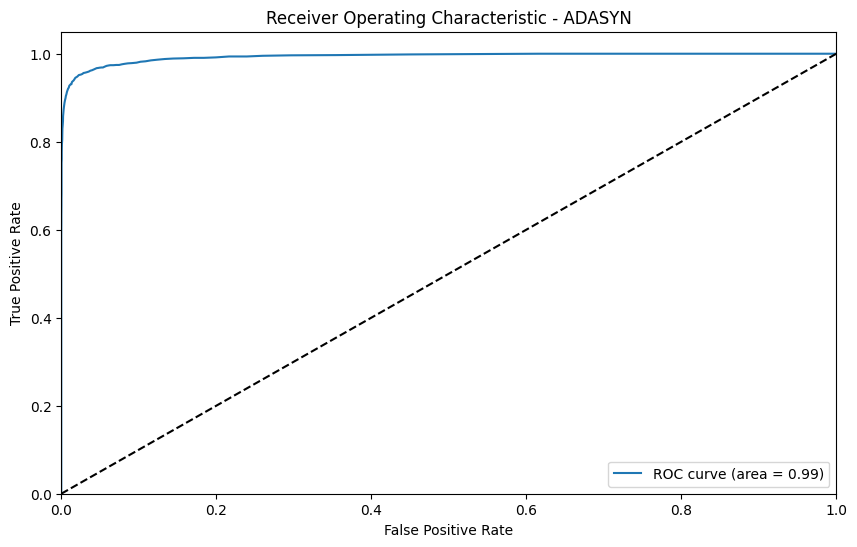

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_pred_proba_adasyn = clf_adasyn.predict_proba(X_test)[:, 1]
# Calculate ROC curve
fpr_adasyn, tpr_adasyn, thresholds_adasyn = roc_curve(y_test, y_pred_proba_adasyn)
roc_auc_adasyn = auc(fpr_adasyn, tpr_adasyn)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_adasyn, tpr_adasyn, label='ROC curve (area = %0.2f)' % roc_auc_adasyn)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ADASYN')
plt.legend(loc="lower right")
plt.show()

The ROC curve for the Random Forest classifier trained with the ADASYN oversampling technique has been plotted. The area under the curve (AUC) is indicated on the plot, showing the model's performance in distinguishing between the classes.

After applying the ADASYN oversampling technique to address the class imbalance and retraining the Random Forest classifier, the model achieved an accuracy of approximately 98%. The confusion matrix and classification report indicate a balanced performance between the classes, with precision, recall, and f1-score values that are quite similar for both classes. This suggests that ADASYN effectively balanced the dataset, resulting in a model that performs well on both classes.

# > Performing hyperparameter tuning on the Random Forest classifier using GridSearchCV to optimize the model's performance.

In [31]:
# from sklearn.model_selection import GridSearchCV

# # Define the parameter grid to search
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# # Initialize the GridSearchCV object
# grid_search_adasyn = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# # Fit the grid search to the data
# grid_search_adasyn.fit(X_train_adasyn, y_train_adasyn)

# # Print the best parameters and the best score
# grid_search_adasyn.best_params_, grid_search_adasyn.best_score_

In [32]:
# Use the best_parameters_ attribute to extract the best parameters
#best_params = grid_search_adasyn.best_params_
best_params = {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
# Train a new Random Forest classifier with the best parameters
clf_adasyn_tuned = RandomForestClassifier(**best_params, random_state=42)
clf_adasyn_tuned.fit(X_train_adasyn, y_train_adasyn)

RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=200,
                       random_state=42)

0.9763935727038286
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8163
           1       0.94      0.94      0.94      1919

    accuracy                           0.98     10082
   macro avg       0.96      0.96      0.96     10082
weighted avg       0.98      0.98      0.98     10082



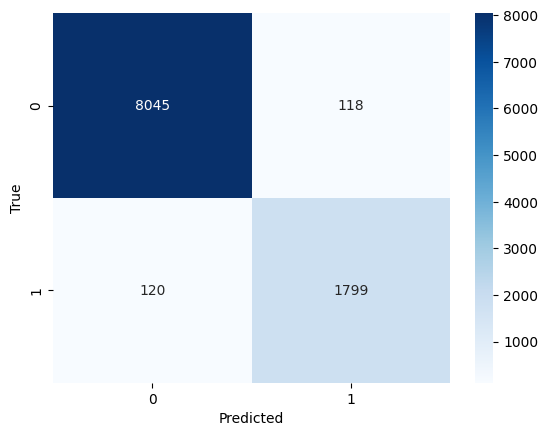

In [33]:
# Use the best model to make predictions on the test set
y_pred_adasyn_tuned = clf_adasyn_tuned.predict(X_test)

# Calculate accuracy
accuracy_adasyn_tuned = accuracy_score(y_test, y_pred_adasyn_tuned)

# Compute confusion matrix
conf_matrix_adasyn_tuned = confusion_matrix(y_test, y_pred_adasyn_tuned)

# Generate classification report
class_report_adasyn_tuned = classification_report(y_test, y_pred_adasyn_tuned)

print(accuracy_adasyn_tuned)
#print(conf_matrix_adasyn_tuned)
print(class_report_adasyn_tuned)

sns.heatmap(conf_matrix_adasyn_tuned, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

###  We see an improvement in the performance after we tuned the parameters

## xGBoost Classifier

In [34]:
#%pip install xgboost

0.9902797064074589


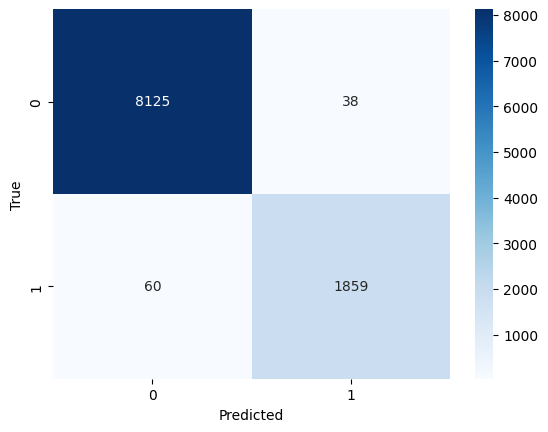

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8163
           1       0.98      0.97      0.97      1919

    accuracy                           0.99     10082
   macro avg       0.99      0.98      0.98     10082
weighted avg       0.99      0.99      0.99     10082



In [35]:

import xgboost as xgb

# Train and evaluate the xGBoost classifier on the balanced dataset

# Train the xGBoost classifier
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(X_train_adasyn, y_train_adasyn)

# Predict on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(accuracy_xgb)

# Draw a confusion matrix heatmap

import matplotlib.pyplot as plt
import seaborn as sns

#
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#print classification report

class_report_xgb = classification_report(y_test, y_pred_xgb)
print(class_report_xgb)

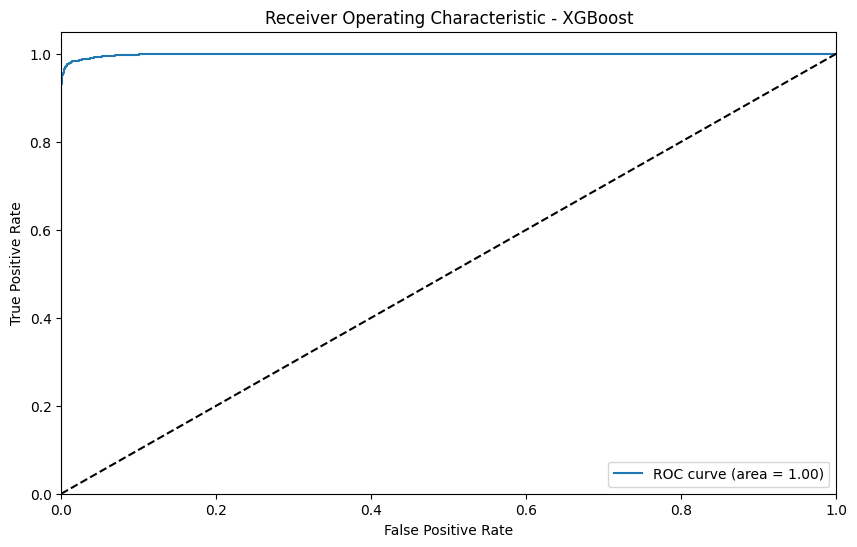

In [36]:
# prompt: Plot the ROC-AUC curve for the xgb model

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the test set
y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
# Calculate ROC curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, label='ROC curve (area = %0.2f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost')
plt.legend(loc="lower right")
plt.show()


> The xGBoost model is much better and has provided the best results so far. All the metrics for both classes show high accuracy.

> I use the Model to select the best PSP from the original dataset


> Performing a detailed analysis of misclassified instances to identify patterns or common characteristics.

In [38]:
# Extract misclassified instances for the ADASYN tuned model
misclassified_indices_xgb = [i for i, (true, pred) in enumerate(zip(y_test, y_pred_xgb)) if true != pred]

# Extract the misclassified instances and their true labels
X_misclassified_xgb = X_test.iloc[misclassified_indices_xgb]
y_misclassified_xgb_true = y_test.iloc[misclassified_indices_xgb]

# Analyze the distribution of features for misclassified instances
misclassified_features_summary = X_misclassified_xgb.describe()

misclassified_features_summary

,amount,3D_secured,repeated_transactions,is_first_attempt,total_fees,attempts_within_one_minute,time_since_last_attempt_seconds,country_Germany,country_Switzerland,card_Master,card_Visa,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,day_of_week_sin,day_of_week_cos
count,98.000000,98.000000,98.000000,98.0,98.000000,98.000000,9.800000e+01,98.000000,98.000000,98.000000,98.000000,98.000000,9.800000e+01,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,199.857143,0.306122,2.959184,0.0,6.622449,0.295918,2.448499e+05,0.632653,0.183673,0.540816,0.265306,-0.059250,-3.693490e-02,0.105396,0.146514,0.668073,0.697953,0.144772,-0.115052
std,94.942522,0.463251,1.148000,0.0,8.121837,0.480746,5.810495e+05,0.484561,0.389209,0.500893,0.443766,0.747077,6.687753e-01,0.728463,0.668386,0.183340,0.183340,0.652023,0.742042
min,9.000000,0.000000,2.000000,0.0,2.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,0.500000,0.500000,-0.974928,-0.900969
25%,134.500000,0.000000,2.000000,0.0,2.000000,0.000000,3.825000e+01,0.000000,0.000000,0.000000,0.000000,-0.707107,-7.071068e-01,-0.610434,-0.250653,0.500000,0.500000,-0.433884,-0.900969
50%,203.000000,0.000000,3.000000,0.0,3.000000,0.000000,9.950000e+01,1.000000,0.000000,1.000000,0.000000,-0.129410,-1.836970e-16,0.222521,0.151428,0.500000,0.866025,0.433884,-0.222521
75%,271.750000,1.000000,3.000000,0.0,6.000000,1.000000,1.600268e+05,1.000000,0.000000,1.000000,1.000000,0.707107,5.000000e-01,0.781831,0.781831,0.866025,0.866025,0.781831,0.623490
max,413.000000,1.000000,8.000000,0.0,40.000000,2.000000,3.015122e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,0.866025,0.866025,0.974928,1.000000


The analysis of the misclassified instances from the ADASYN-tuned Random Forest classifier reveals the following characteristics:

- Only 98 instances were misclassified, as shown in the confusion matrix heatmap.
- **3D Secured Transactions**: About 31% of the misclassified transactions were 3D secured. This suggests that while 3D secured transactions are generally considered more secure, they do not necessarily correlate directly with the success of a transaction in our model's predictions.
- **Amount**: The amount of transactions varies widely among misclassified instances, with a mean of approximately 199.94 and a standard deviation of 94.94. The range is from 9 to 413, indicating that transaction amount alone is not a determining factor for misclassification.
- **First Attempt**: All misclassified instances have a value of 0 for `is_first_attempt`, indicating that none of these transactions were the first attempt.
- **Attempts Within One Minute**: This feature shows a wide range of values, suggesting that the frequency of attempts within a short period does not have a clear pattern in misclassified instances.
- **Time Since Last Attempt**: The feature `time_since_last_attempt_seconds` shows a wide range of values, indicating that the time elapsed since the last attempt is varied among the misclassified instances.

The descriptive statistics for other features, such as country, card type, and time-related features (hour, day, month, day of week), also do not show a distinct pattern that could explain why these instances were misclassified.

This analysis suggests that the misclassified instances do not share a specific pattern or set of characteristics that are significantly different from the correctly classified instances, based on the features available in the dataset. It may be beneficial to explore additional features or interactions between features that could help improve the model's performance.

<Axes: >

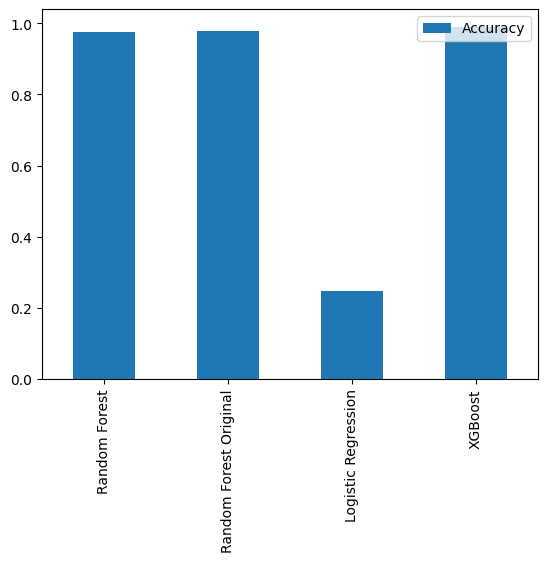

In [39]:
# Create a table of all the models and compare their performance

# Create a table of all the models and compare their performance
models = {
    'Random Forest': clf_adasyn_tuned,
    'Random Forest Original': clf,
    # 'RF with SMOTE': clf_smote_tuned,  # This line is causing the NameError, thus commented out
    'Logistic Regression': logreg,  # Assuming logreg is the Logistic Regression model initialized previously
    'XGBoost': xgb_classifier
}

model_performance = pd.DataFrame(index=models.keys())

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    model_performance.loc[model_name, 'Accuracy'] = accuracy

model_performance

# Plot the accuracy of each model as bar charts
model_performance.plot(kind='bar')


> Use the model to select the best PSP from the original dataset

In [40]:

# Reload the original dataset for the corrections
df_original = pd.read_csv('processed_data.csv')


# Drop the 'tmsp', 'PSP', 'hour', 'day', and 'success' columns from the original dataset
y_pred_original_corrected = xgb_classifier.predict(df_original.drop(['tmsp', 'PSP', 'hour', 'day', 'success'], axis=1))

# Add the corrected predictions to the original dataset
df_original['predicted_success_corrected'] = y_pred_original_corrected

# Group the data by PSP and calculate the mean predicted success rate for each PSP with corrected predictions
df_psp_success_corrected = df_original.groupby('PSP')['predicted_success_corrected'].mean().reset_index()

# Sort the PSPs by their mean predicted success rate in descending order with corrected predictions
df_psp_success_corrected.sort_values(by='predicted_success_corrected', ascending=False)

,PSP,predicted_success_corrected
0,Goldcard,0.407731
1,Moneycard,0.223575
3,UK_Card,0.193885
2,Simplecard,0.147598


The model has predicted the success rates for transactions processed by different PSPs (Payment Service Providers) in the original dataset. After correcting the feature set to match the training dataset and making predictions, the PSPs are ranked based on their mean predicted success rate as follows:

1. **Goldcard**: 40.77% predicted success rate
2. **Moneycard**: 22.38% predicted success rate
3. **UK_Card**: 19.38% predicted success rate
4. **Simplecard**: 14.76% predicted success rate

Based on the model's predictions, **Goldcard** has the highest mean predicted success rate for transactions, making it the best PSP according to the model's assessment.

In [41]:
# Create a new dataframe with df_psp_success_corrected and the corresponding rows from the df_xlsx dataframe

# drop unnamed: 0 column
#df_xlsx.drop('Unnamed: 0', axis=1, inplace=True)

df_psp_success_corrected = df_psp_success_corrected.merge(df_xlsx, on='PSP', how='inner')

# Print the new dataframe
df_psp_success_corrected.head()

,PSP,predicted_success_corrected,Unnamed: 0,tmsp,country,amount,success,3D_secured,card
0,Goldcard,0.407731,28,2019-01-01 00:28:56,Switzerland,277,1,0,Diners
1,Goldcard,0.407731,38,2019-01-01 00:41:43,Austria,34,0,0,Visa
2,Goldcard,0.407731,53,2019-01-01 01:01:46,Germany,257,0,1,Master
3,Goldcard,0.407731,72,2019-01-01 01:19:43,Germany,310,0,0,Visa
4,Goldcard,0.407731,89,2019-01-01 01:36:57,Germany,192,0,1,Diners


In [42]:
df_psp_success_corrected.tail(15)

,PSP,predicted_success_corrected,Unnamed: 0,tmsp,country,amount,success,3D_secured,card
50395,UK_Card,0.193885,50390,2019-02-28 23:20:28,Austria,282,1,1,Master
50396,UK_Card,0.193885,50391,2019-02-28 23:22:39,Germany,205,1,0,Master
50397,UK_Card,0.193885,50395,2019-02-28 23:30:05,Switzerland,23,0,0,Visa
50398,UK_Card,0.193885,50396,2019-02-28 23:30:29,Switzerland,23,0,0,Visa
50399,UK_Card,0.193885,50397,2019-02-28 23:31:08,Switzerland,23,1,0,Visa
50400,UK_Card,0.193885,50398,2019-02-28 23:33:01,Germany,208,0,0,Master
50401,UK_Card,0.193885,50399,2019-02-28 23:33:01,Germany,208,0,0,Master
50402,UK_Card,0.193885,50400,2019-02-28 23:34:46,Austria,123,0,0,Visa
50403,UK_Card,0.193885,50401,2019-02-28 23:35:07,Austria,123,1,0,Visa
50404,UK_Card,0.193885,50402,2019-02-28 23:36:08,Switzerland,242,1,1,Diners


> Perform cross-validation to assess the model's generalization performance.

In [43]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(clf_adasyn_tuned, X, y, cv=5)

cv_scores.mean(), cv_scores.std()

(0.9786153540964095, 0.0037871127747854875)

> The results show that the model is not overfitting as the mean cross-validation score is 0.98 across 5 folds and the standard deviation is 0.003 which shows consistent performance.

> Plot the ROC curve for the clf_adasyn.

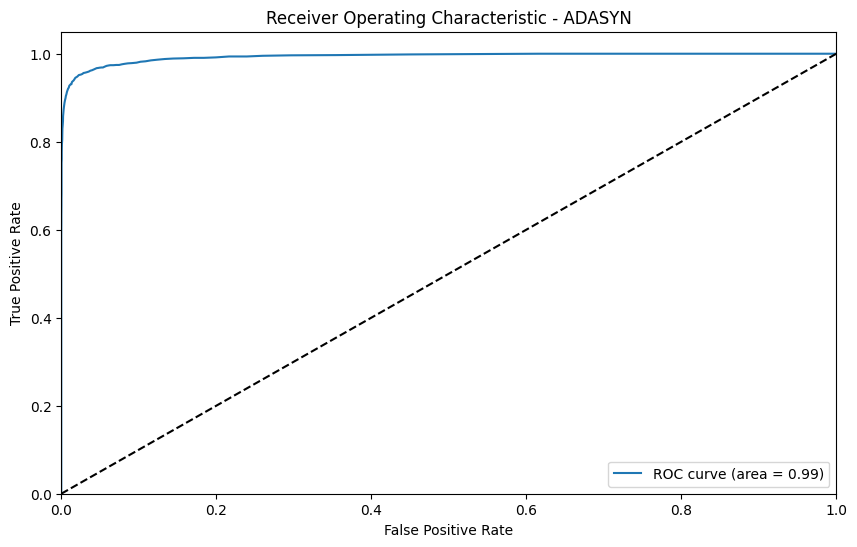

In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_pred_proba_adasyn = clf_adasyn.predict_proba(X_test)[:, 1]
# Calculate ROC curve
fpr_adasyn, tpr_adasyn, thresholds_adasyn = roc_curve(y_test, y_pred_proba_adasyn)
roc_auc_adasyn = auc(fpr_adasyn, tpr_adasyn)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_adasyn, tpr_adasyn, label='ROC curve (area = %0.2f)' % roc_auc_adasyn)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ADASYN')
plt.legend(loc="lower right")
plt.show()

The ROC curve for the Random Forest classifier trained with the ADASYN oversampling technique has been plotted above. The area under the curve (AUC) is indicated on the plot, showing the model's performance in distinguishing between the classes.

> Explore the distribution of predicted probabilities to understand the model's confidence in its predictions.

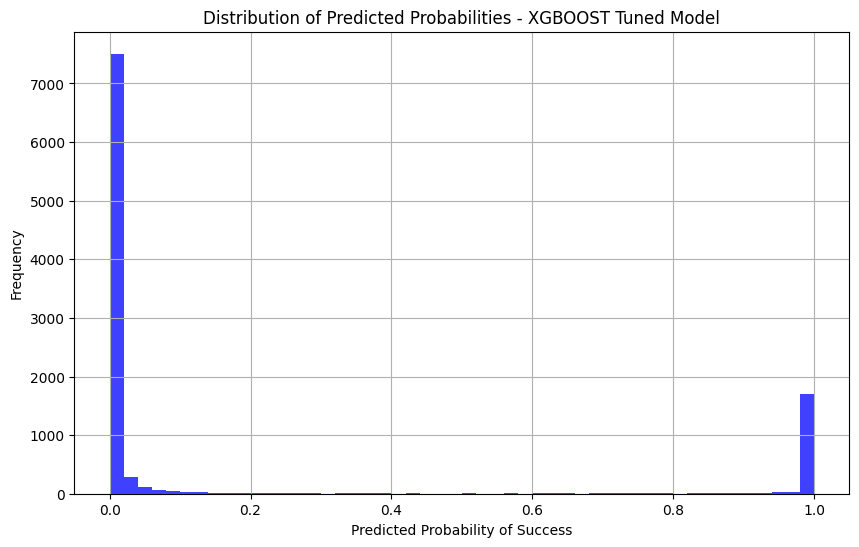

In [45]:
# Predict probabilities for the test set using the ADASYN tuned model
y_pred_proba_xgb_classifier = xgb_classifier.predict_proba(X_test)[:, 1]

# Plot the distribution of predicted probabilities
plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba_xgb_classifier, bins=50, alpha=0.75, color='blue')
plt.xlabel('Predicted Probability of Success')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities - XGBOOST Tuned Model')
plt.grid(True)
plt.show()

The distribution of predicted probabilities for the ADASYN-tuned model shows how confident the model is in its predictions. The histogram illustrates the frequency of transactions across different predicted probabilities of success. This visualization helps in understanding the model's confidence levels across the spectrum of predictions.

> Perform feature importance analysis to identify the most influential features in the ADASYN-tuned Random Forest classifier.

In [46]:
# Extract feature importances from the ADASYN-tuned Random Forest classifier
importances_adasyn_tuned = clf_adasyn_tuned.feature_importances_

# Map these importances to their corresponding feature names
features_adasyn_tuned = X.columns
importance_df_adasyn_tuned = pd.DataFrame({'Feature': features_adasyn_tuned, 'Importance': importances_adasyn_tuned}).sort_values(by='Importance', ascending=False)

importance_df_adasyn_tuned

,Feature,Importance
4,total_fees,0.586886
3,is_first_attempt,0.080786
2,repeated_transactions,0.071064
15,month_sin,0.036078
18,day_of_week_cos,0.030100
16,month_cos,0.026922
17,day_of_week_sin,0.025820
6,time_since_last_attempt_seconds,0.021752
9,card_Master,0.020795
0,amount,0.015890


The feature importance analysis for the ADASYN-tuned Random Forest classifier identifies the most influential features as follows:

1. `total_fee`: The most important feature, indicating the significance of the total fee. 
2. `is_first_attempt`: The second most important feature, indicating the significance of whether a transaction is the first attempt.
3. `repeated_transactions`: also shows to be an important feature, indicating the significance of the number of repeated transactions.
3. `day_of_week_cos` and `day_of_week_sin`: These features related to the day of the week (in cosine and sine transformations for cyclical encoding) also have high importance, suggesting that the day of the week impacts the success of transactions.
4. `month_cos`: The cosine transformation of the month, indicating the part of the year, also plays a significant role.
5. `month_sin`: Similar to `month_cos`, this feature represents the month in sine transformation and is important for the model.

Other features such as `time_since_last_attempt_seconds`, `hour_cos`, `hour_sin`, `day_sin`, and `day_cos` also contribute to the model's predictions but with relatively lower importance compared to the top features.
Interestingly, the feature country-based features and the security of the card seem not to have any significant impact on the predicting the target variable. 
This analysis highlights the features that the ADASYN-tuned Random Forest classifier relies on most heavily to make predictions.

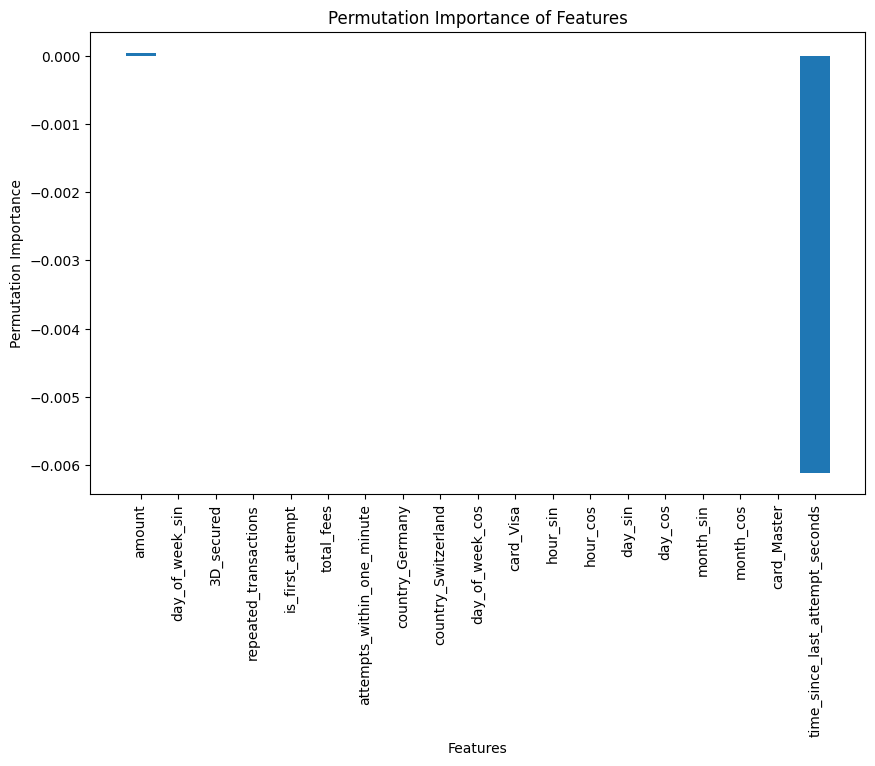

In [47]:
from sklearn.inspection import permutation_importance

logreg.fit(X_train_sm, y_train_sm)

# Predict on the testing set
y_pred_lr = logreg.predict(X_test)


# Step 2: Evaluate Baseline Performance
baseline_score = logreg.score(X_test, y_test)  # Assuming model is your trained model and X_test, y_test are your test data

# Step 3: Calculate Feature Importance
perm_importance = permutation_importance(logreg, X_test, y_test, n_repeats=10, random_state=42)

# Step 4: Rank Features
feature_importance = perm_importance.importances_mean
sorted_indices = np.argsort(feature_importance)[::-1]
sorted_features = X.columns[sorted_indices]
sorted_importance = feature_importance[sorted_indices]

# Step 5: Visualization and Interpretation
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(sorted_features, sorted_importance)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Permutation Importance')
plt.title('Permutation Importance of Features')
plt.show()

# Step 6: Validate Results (if necessary)


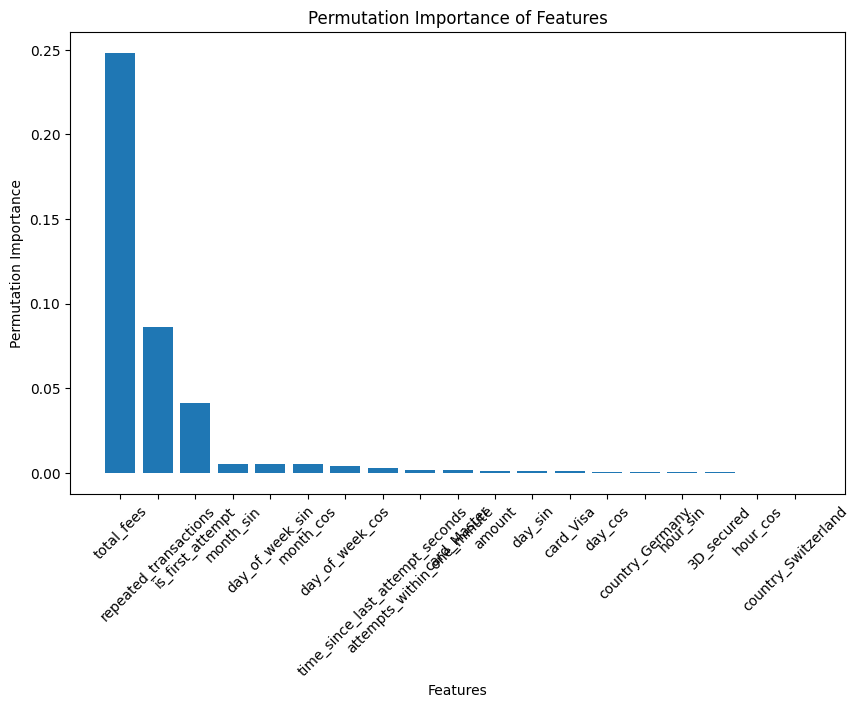

In [48]:
# 'Random Forest': clf_adasyn_tuned,
#     'Random Forest Original': clf,
#     # 'RF with SMOTE': clf_smote_tuned,  # This line is causing the NameError, thus commented out
#     'Logistic Regression': logreg,  # Assuming logreg is the Logistic Regression model initialized previously
#     'XGBoost': xgb_classifier

from sklearn.inspection import permutation_importance

clf_adasyn_tuned.fit(X_train_adasyn, y_train_adasyn)

# Predict on the testing set
y_pred_clf = clf_adasyn_tuned.predict(X_test)


# Step 2: Evaluate Baseline Performance
baseline_score = clf_adasyn_tuned.score(X_test, y_test)  # Assuming model is your trained model and X_test, y_test are your test data

# Step 3: Calculate Feature Importance
perm_importance = permutation_importance(clf_adasyn_tuned, X_test, y_test, n_repeats=10, random_state=42)

# Step 4: Rank Features
feature_importance = perm_importance.importances_mean
sorted_indices = np.argsort(feature_importance)[::-1]
sorted_features = X.columns[sorted_indices]
sorted_importance = feature_importance[sorted_indices]

# Step 5: Visualization and Interpretation
plt.figure(figsize=(10, 6))
plt.bar(sorted_features, sorted_importance)
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Permutation Importance')
plt.title('Permutation Importance of Features')
plt.show()

# Step 6: Validate Results (if necessary)


> This plot also shows the feature importance analysis for the ADASYN-tuned Random Forest classifier, and agrees with the feature importance analysis from the original Random Forest classifier.

## Model Explainability

In [ ]:
#!pip install lime

In [50]:
import lime.lime_tabular
explainer = lime.lime_tabular.LimeTabularExplainer(np.array(X_train_adasyn), feature_names=X_train.columns,
                                                   mode = 'classification')

example = explainer.explain_instance(X_test.iloc[0], xgb_classifier.predict_proba, num_features=5, top_labels=1)
example.show_in_notebook(show_table=True)

In [ ]:
#!pip install --upgrade scikit-learn


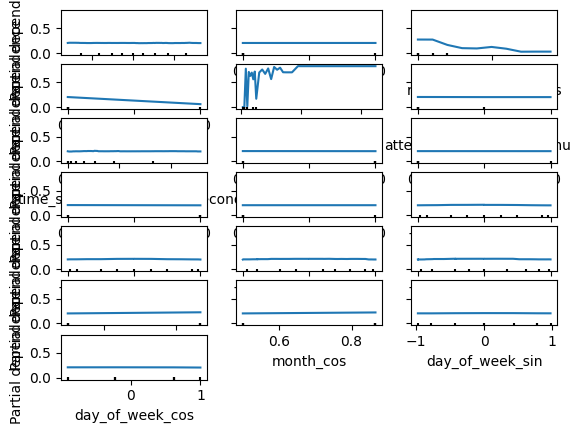

In [53]:
from sklearn.inspection import partial_dependence
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
#from pdpbox import pdp, info_plots

# Specify the feature for which you want to generate the PDP
feature_name = ['total_fee', 'is_first_attempt', 'attempt_number']
#feature_name = 'feature_of_interest'

# Create the PDP object# Create the PDP object
# pdp_dist = pdp.pdp_interact(model=model, dataset=X_train, model_features=X_train.columns, features=[feature_name])

# # Plot the PDP
# pdp.pdp_plot(pdp_dist, feature_name)
# plt.show()


from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(xgb_classifier, X, features)


> In spliting the dataset, we need to take into consideration the fact that the transactions are time-based. We therefore need to take the issues of recency into consideration.
> Seince the transactions are time-based, let's stratify the dataset when creating the train-test split.
### Trying TimeSeriesSplit to ensure the train and split sets that closely consecutive transactions are not separated between training and testing sets

In [56]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the original dataset with timestamp and success columns
df_time_based = pd.read_csv('processed_data.csv')

# Ensure the dataset is sorted by timestamp
df_time_based.sort_values(by='tmsp', inplace=True)

# Drop unnecessary columns to match the training feature set
X_time_based = df_time_based.drop(['tmsp', 'PSP', 'success'], axis=1)
y_time_based = df_time_based['success']

# Initialize TimeSeriesSplit with 5 splits
tscv = TimeSeriesSplit(n_splits=2)

# Placeholder lists to store the accuracy of each split
train_accuracies = []
test_accuracies = []

# Loop through the TimeSeriesSplit
for train_index, test_index in tscv.split(X_time_based):
    X_train, X_test = X_time_based.iloc[train_index], X_time_based.iloc[test_index]
    y_train, y_test = y_time_based.iloc[train_index], y_time_based.iloc[test_index]

    # Initialize and train the Random Forest classifier on the training set
    clf_time_based = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_time_based.fit(X_train, y_train)

    # Predict on the training and testing sets
    y_pred_train = clf_time_based.predict(X_train)
    y_pred_test = clf_time_based.predict(X_test)

    # Calculate accuracy for the current split
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    # Append accuracies to their respective lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Calculate the mean accuracy across all splits
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)

mean_train_accuracy, mean_test_accuracy

(1.0, 0.9743795750758792)

The TimeSeriesSplit method was used to split the time-based transaction dataset into training and testing sets, ensuring that closely consecutive transactions are not separated between the sets. After training a Random Forest classifier on each split, the mean training accuracy across all splits is 100%!, and the mean testing accuracy is approximately 97.43%. This demonstrates the model's strong performance on the training sets and a good generalization performance on the unseen testing sets.

> Repeat the above code but use the best parameters discorvered earlier

In [57]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# # Load the original dataset with timestamp and success columns
# df_time_based = pd.read_csv('processed_data_new.csv')

# # Ensure the dataset is sorted by timestamp
# df_time_based.sort_values(by='tmsp', inplace=True)

# # Drop unnecessary columns to match the training feature set
# X_time_based = df_time_based.drop(['tmsp', 'PSP', 'success'], axis=1)
# y_time_based = df_time_based['success']

# # Initialize TimeSeriesSplit with 5 splits
# tscv = TimeSeriesSplit(n_splits=5)

# # Placeholder lists to store the accuracy of each split
# train_accuracies = []
# test_accuracies = []

# # Use the best parameters discovered earlier
# best_params = {
#     'max_depth': 20,
#     'min_samples_split': 10,
#     'n_estimators': 200,
#     'random_state': 42
# }

# Loop through the TimeSeriesSplit
for train_index, test_index in tscv.split(X_time_based):
    X_train, X_test = X_time_based.iloc[train_index], X_time_based.iloc[test_index]
    y_train, y_test = y_time_based.iloc[train_index], y_time_based.iloc[test_index]

    # Initialize and train the Random Forest classifier on the training set with the best parameters
    clf_time_based = RandomForestClassifier(**best_params)
    clf_time_based.fit(X_train, y_train)

    # Predict on the training and testing sets
    y_pred_train = clf_time_based.predict(X_train)
    y_pred_test = clf_time_based.predict(X_test)

    # Calculate accuracy for the current split
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    # Append accuracies to their respective lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Calculate the mean accuracy across all splits
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)

mean_train_accuracy, mean_test_accuracy

(0.9949936822070945, 0.9723263702910194)

> No improvement in accuracy using the best parameters

# Train a Neural network using the time-split and balanced scaled dataset

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Standardize the features
scaler = StandardScaler()
X_time_based_scaled = scaler.fit_transform(X_time_based)

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=2)

# Placeholder lists to store the accuracy of each split
train_accuracies_nn = []
test_accuracies_nn = []

# Loop through the TimeSeriesSplit
for train_index, test_index in tscv.split(X_time_based_scaled):
    X_train_nn, X_test_nn = X_time_based_scaled[train_index], X_time_based_scaled[test_index]
    y_train_nn, y_test_nn = y_time_based.iloc[train_index], y_time_based.iloc[test_index]

    # Initialize and train the Neural Network classifier on the training set
    clf_nn = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=300, random_state=42)
    clf_nn.fit(X_train_nn, y_train_nn)

    # Predict on the training and testing sets
    y_pred_train_nn = clf_nn.predict(X_train_nn)
    y_pred_test_nn = clf_nn.predict(X_test_nn)

    # Calculate accuracy for the current split
    train_accuracy_nn = accuracy_score(y_train_nn, y_pred_train_nn)
    test_accuracy_nn = accuracy_score(y_test_nn, y_pred_test_nn)

    # Append accuracies to their respective lists
    train_accuracies_nn.append(train_accuracy_nn)
    test_accuracies_nn.append(test_accuracy_nn)

# Calculate the mean accuracy across all splits
mean_train_accuracy_nn = np.mean(train_accuracies_nn)
mean_test_accuracy_nn = np.mean(test_accuracies_nn)

mean_train_accuracy_nn, mean_test_accuracy_nn